In [15]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Lr current 

In [3]:
df = pd.read_csv("2026-02-10_16-12-50-922.csv")
CH1 = df.CH1.values
CH2 = df.CH2.values
time = df.time.values


In [8]:
Ts= df.Ts.iloc[0]

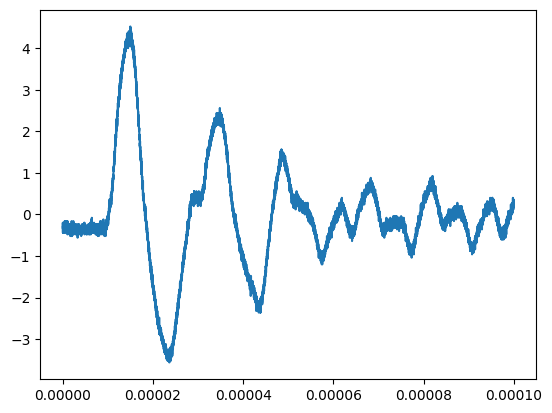

In [4]:
plt.plot(time, CH2)

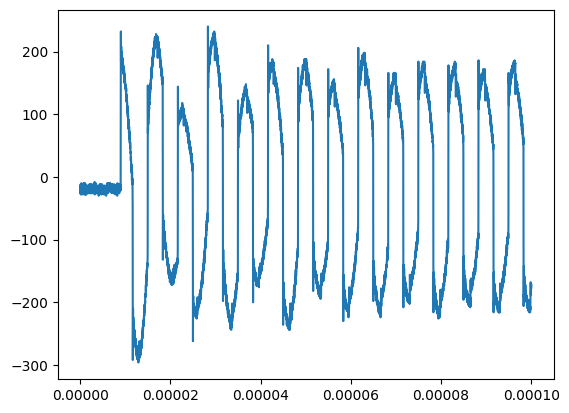

In [5]:
plt.plot(time, CH1)

sklearn.linear_model._base.LinearRegression

array([[0.000e+00],
       [1.000e-08],
       [2.000e-08],
       ...,
       [9.997e-05],
       [9.998e-05],
       [9.999e-05]], shape=(10000, 1))

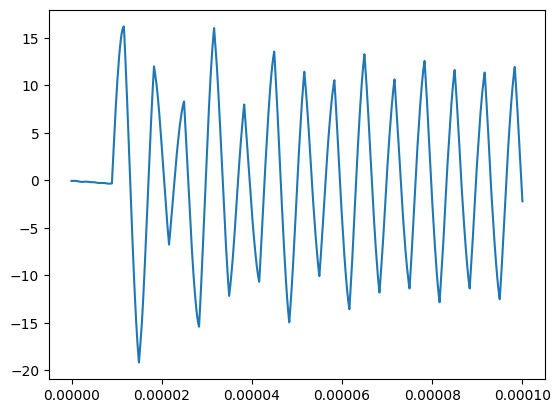

In [19]:
Lr = 21e-6
# i = L dv/dt 
ir = np.cumsum(CH1)*Ts/Lr
y= ir 
x = time.reshape((-1,1))
ir = y-LinearRegression().fit(x, y).predict(x)
plt.plot(time , ir)

# Cr current 

In [24]:
df = pd.read_csv("2026-02-10_16-09-27-087.csv")
CH1 = df.CH1.values
CH2 = df.CH2.values
time = df.time.values
Ts= df.Ts.iloc[0]

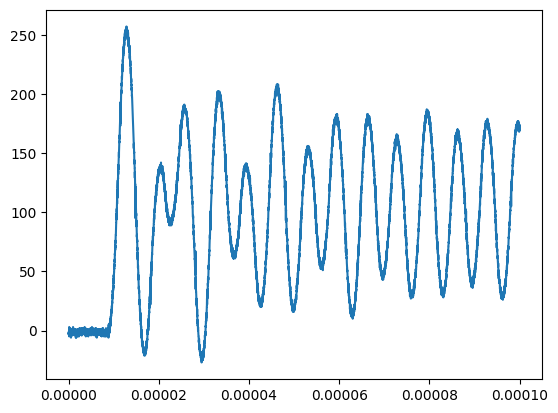

In [21]:
plt.plot(time, CH1)

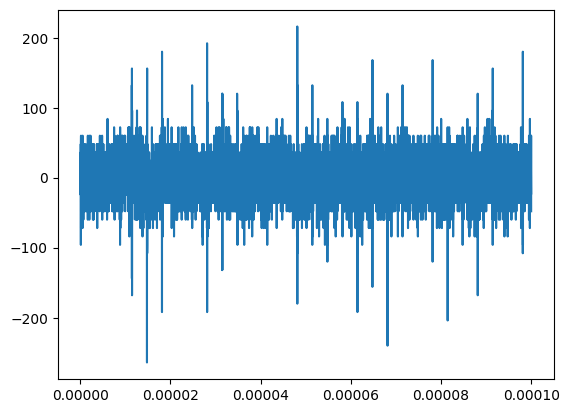

In [28]:
Cr = 120e-9
# i = c dv/dt
ic = Cr*np.diff(CH1)/Ts
plt.plot(time[1:], ic)

In [31]:
1e-6/Ts

np.float64(100.0)

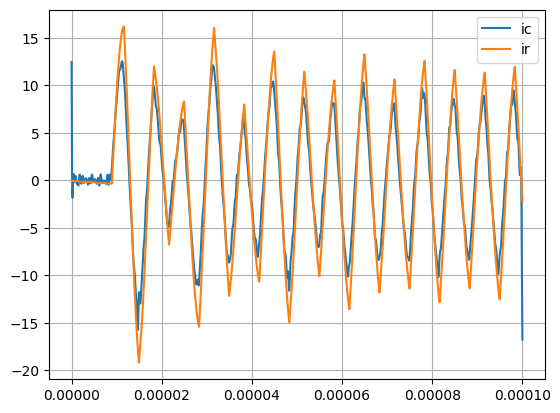

In [40]:
from scipy.signal import butter

fc = 2e6  # cutoff frequency in Hz
fs = 1 / Ts  # sampling frequency
b, a = butter(N=4, Wn=fc/(fs/2), btype='low')  # 4th order low-pass
from scipy.signal import filtfilt

ic2 = filtfilt(b, a, ic)
plt.plot(time[1:], ic2, label = "ic")
plt.plot(time , ir, label = "ir")
plt.legend()
plt.grid()